In [6]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from pathlib import Path

# Save under a predictable folder next to the project/notebook
try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    # Jupyter notebook fallback
    script_dir = Path.cwd()

save_dir = script_dir / "saved_models"
save_dir.mkdir(parents=True, exist_ok=True)

custom_save_path = save_dir / "custom.keras"
custom_model.save(custom_save_path)

print(f"Saved model to: {custom_save_path}")

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# neural networks
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models

# pre-trained models
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50  # ResNet (50 layers)
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2  # MobileNet (version 2)
from tensorflow.keras.applications.efficientnet import EfficientNetB5  # EfficientNet

Saved model to: C:\Users\anluo\PyCharmMiscProject\Project_4\saved_models\custom.keras


In [7]:
# Pre-work codes
def accuracy_score_np(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    if y_true.size == 0:
        return 0.0
    return float(np.mean(y_true == y_pred))

def f1_score_macro_np(y_true, y_pred, num_classes: int | None = None) -> float:
    """
    Macro-F1 for single-label multiclass classification.
    Uses per-class F1 (with 0 when precision+recall==0), then averages across classes.
    """
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)

    if y_true.size == 0:
        return 0.0

    if num_classes is None:
        num_classes = int(max(y_true.max(initial=0), y_pred.max(initial=0)) + 1)

    f1s = []
    for c in range(num_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))

        denom = (2 * tp + fp + fn)
        f1_c = (2 * tp / denom) if denom != 0 else 0.0
        f1s.append(f1_c)

    return float(np.mean(f1s))


In [8]:
# Pre-trained Models
def evaluate_model(model: tf.keras.Model, dataset: tf.data.Dataset, num_classes: int) -> dict:
    y_true = []
    y_pred = []

    for batch_images, batch_labels in dataset:
        probs = model.predict(batch_images, verbose=0)
        pred_labels = np.argmax(probs, axis=1)

        y_true.extend(batch_labels.numpy().tolist())
        y_pred.extend(pred_labels.tolist())

    acc = accuracy_score_np(y_true, y_pred)
    f1 = f1_score_macro_np(y_true, y_pred, num_classes=num_classes)

    return {"accuracy": float(acc), "f1_score": float(f1)}

Found 2392 files belonging to 2 classes.
Using 1914 files for training.
Found 2392 files belonging to 2 classes.
Using 478 files for validation.
Found 597 files belonging to 2 classes.
['flip', 'notflip']


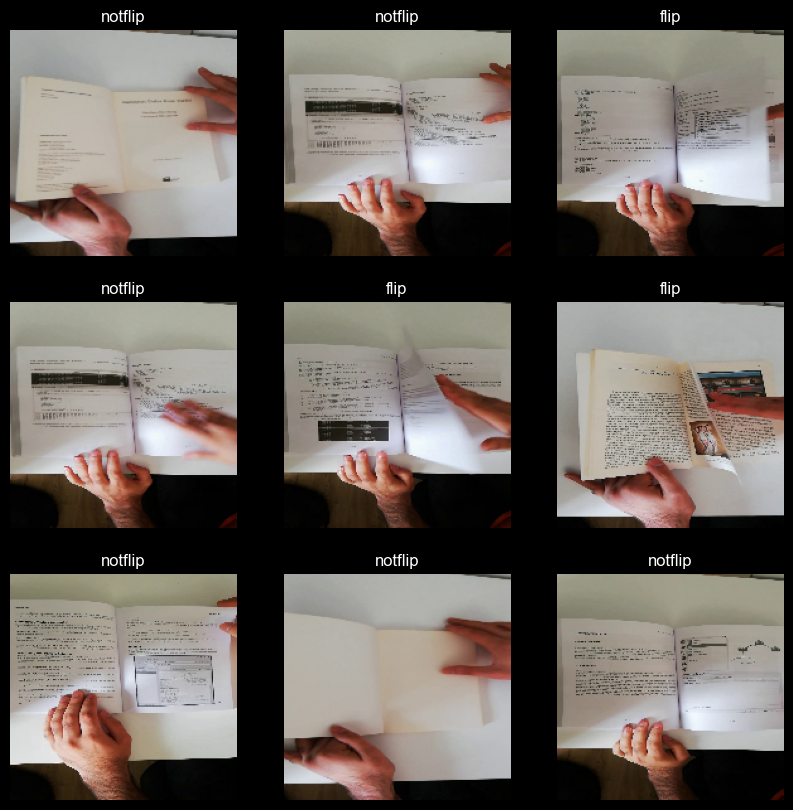

In [9]:
# Data Exploration
train_data_dir = 'C:/Users/anluo/OneDrive/Desktop/Projects/Project 4/images/training'
test_data_dir = 'C:/Users/anluo/OneDrive/Desktop/Projects/Project 4/images/testing'
img_height, img_width, img_chns = 180, 180, 3
batch_size = 32

train_imgs = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_imgs = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

test_imgs = tf.keras.preprocessing.image_dataset_from_directory(
    test_data_dir,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

classes = train_imgs.class_names
num_classes = len(classes)
print(classes)

plt.figure(figsize=(10, 10))
for images, labels in train_imgs.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(classes[int(labels[i])])
        plt.axis("off")

plt.show()

C:\Users\anluo\Anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 87, 87, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 59168)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     3,786,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,797,090 (14.48 MB)

 Trainable params: 3,797,090 (14.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.5940 - loss: 107.6631 - val_accuracy: 0.6736 - val_loss: 0.6264
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.7759 - loss: 0.4071 - val_accuracy: 0.8577 - val_loss: 0.3194
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.9410 - loss: 0.1533 - val_accuracy: 0.9561 - val_loss: 0.1099
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.9801 - loss: 0.0573 - val_accuracy: 0.9623 - val_loss: 0.0898
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.9979 - loss: 0.0114 - val_accuracy: 0.9854 - val_loss: 0.0398
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - accuracy: 0.9869 - loss: 0.0382 - val_accuracy: 0.9686 - val_loss: 0.1650
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.9833 - loss: 0.0539 - val_accuracy: 0.9247 - val_loss: 0.1733
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.9937 - loss: 0.0204 - val_accuracy: 

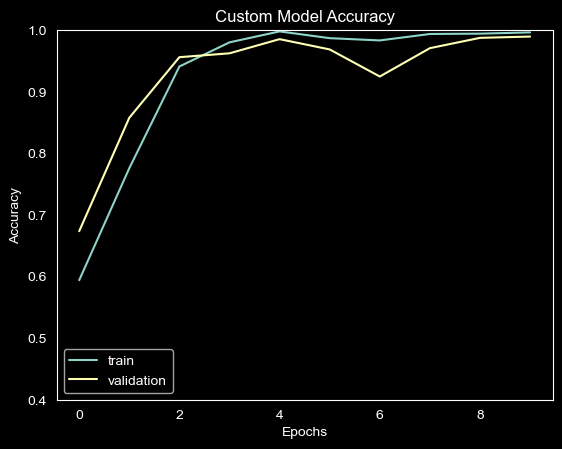

{'accuracy': 0.9882747068676717, 'f1_score': 0.9882640380807953}
custom model size: 45.60 MB


In [10]:
# Custom CNN Model

custom_model = models.Sequential([
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(img_height, img_width, img_chns)
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu'
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(classes), activation='softmax'),
])
custom_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
custom_model.summary()
custom_model_history =custom_model.fit(
    train_imgs,
    epochs=10,
    validation_data=val_imgs
)

fig1 = plt.gcf()
plt.plot(custom_model_history.history['accuracy'])
plt.plot(custom_model_history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Custom Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()
custom_model_evaluation = evaluate_model(custom_model, test_imgs, num_classes)
print(custom_model_evaluation)

# Saving
sizes = {}

# Save under a predictable folder next to this script (more portable than hardcoding)
save_dir = os.path.join(script_dir, "saved_models")
os.makedirs(save_dir, exist_ok=True)

custom_save_path = os.path.join(save_dir, "custom.keras")
custom_model.save(custom_save_path)

sizes["custom"] = os.path.getsize(custom_save_path) / 1e6
custom = sizes["custom"]
print(f"custom model size: {sizes['custom']:.2f} MB")

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 55s 914ms/step - accuracy: 0.7534 - loss: 1.7782 - val_accuracy: 0.9079 - val_loss: 0.2661
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 904ms/step - accuracy: 0.9065 - loss: 0.3654 - val_accuracy: 0.9623 - val_loss: 0.1173
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 906ms/step - accuracy: 0.9425 - loss: 0.1662 - val_accuracy: 0.9749 - val_loss: 0.0731
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 909ms/step - accuracy: 0.9551 - loss: 0.1448 - val_accuracy: 0.9770 - val_loss: 0.0577
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 905ms/step - accuracy: 0.9655 - loss: 0.0845 - val_accuracy: 0.9812 - val_loss: 0.0619
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 907ms/step - accuracy: 0.9786 - loss: 0.0589 - val_accuracy: 0.9812 - val_loss: 0.0501
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 54s 906ms/step - accuracy: 0.9859 - loss: 0.0375 - val_accuracy: 0.9833 - val_loss: 0.0381
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 55s 912ms/step - accuracy: 0.9911 - loss: 0.0311 - val_accu

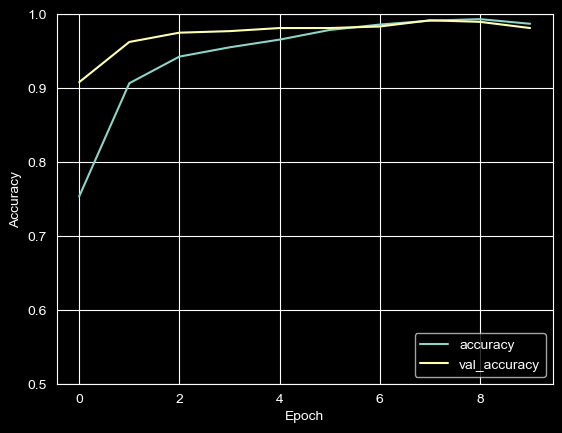

VGG16 model size: 65.28 MB


In [11]:
# VGG-16
def vgg_transfer(train_imgs, val_imgs, test_imgs, img_height, img_width, img_chns, classes):
    num_classes = len(classes)

    vgg16 = VGG16(
        weights='imagenet',
        input_shape=(img_height, img_width, img_chns),
        include_top=False,
        pooling='avg'  # outputs a vector already (GlobalAveragePooling2D)
    )

    for layer in vgg16.layers:
        layer.trainable = False

    x = vgg16.output
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    vgg_model = Model(inputs=vgg16.input, outputs=output_layer)
    vgg_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

    trained_vgg16 = vgg_model.fit(
        train_imgs,
        epochs=10,
        validation_data=val_imgs
    )
    return vgg_model, trained_vgg16


# Training
vgg_model, trained_vgg16 = vgg_transfer(
    train_imgs, val_imgs, test_imgs, img_height, img_width, img_chns, classes
)

# Evaluation
fig2 = plt.gcf()
plt.plot(trained_vgg16.history["accuracy"], label="accuracy")
plt.plot(trained_vgg16.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0.5, 1])
plt.legend(loc="lower right")
plt.show()

# Saving
sizes = {}

# Save under a predictable folder next to this script (more portable than hardcoding)
save_dir = os.path.join(script_dir, "saved_models")
os.makedirs(save_dir, exist_ok=True)

vgg_save_path = os.path.join(save_dir, "vgg16.keras")
vgg_model.save(vgg_save_path)

sizes["vgg"] = os.path.getsize(vgg_save_path) / 1e6
vgg16 = sizes["vgg"]
print(f"VGG16 model size: {sizes['vgg']:.2f} MB")

vgg_model_evaluation = evaluate_model(vgg_model, test_imgs, num_classes=num_classes)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 37s 554ms/step - accuracy: 0.7534 - loss: 0.9218 - val_accuracy: 0.9142 - val_loss: 0.2751
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 529ms/step - accuracy: 0.9274 - loss: 0.2082 - val_accuracy: 0.9582 - val_loss: 0.1618
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 528ms/step - accuracy: 0.9295 - loss: 0.1804 - val_accuracy: 0.9665 - val_loss: 0.1204
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 529ms/step - accuracy: 0.9572 - loss: 0.1203 - val_accuracy: 0.9644 - val_loss: 0.0933
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 586ms/step - accuracy: 0.9483 - loss: 0.1249 - val_accuracy: 0.9561 - val_loss: 0.1039
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 36s 603ms/step - accuracy: 0.9676 - loss: 0.0892 - val_accuracy: 0.9833 - val_loss: 0.0582
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 527ms/step - accuracy: 0.9781 - loss: 0.0693 - val_accuracy: 0.9644 - val_loss: 0.0784
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 523ms/step - accuracy: 0.9796 - loss: 0.0563 - val_accu

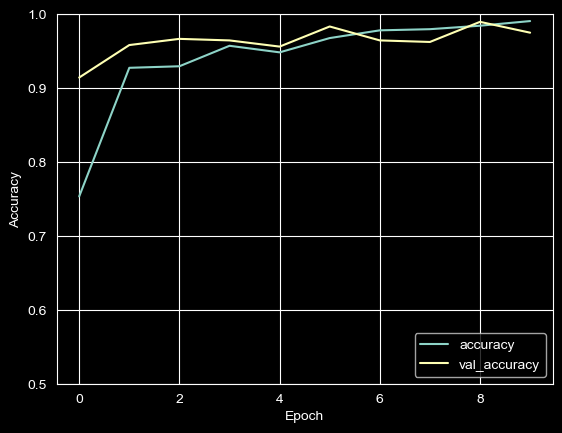

Resnet model size: 120.21 MB


In [12]:
# Resnet
def resnet_transfer(train_imgs, val_imgs, test_imgs, img_height, img_width, img_chns, classes):
    num_classes = len(classes)

    resnet = ResNet50(
        weights='imagenet',
        input_shape=(img_height, img_width, img_chns),
        include_top=False,
        pooling='avg'  # outputs a vector already (GlobalAveragePooling2D)
    )

    for layer in resnet.layers:
        layer.trainable = False

    x = resnet.output
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    resnet_model = Model(inputs=resnet.input, outputs=output_layer)
    resnet_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

    trained_resnet = resnet_model.fit(
        train_imgs,
        epochs=10,
        validation_data=val_imgs
    )
    return resnet_model, trained_resnet


# Training
resnet_model, trained_resnet = resnet_transfer(
    train_imgs, val_imgs, test_imgs, img_height, img_width, img_chns, classes
)

# Evaluation
fig3 = plt.gcf()
plt.plot(trained_resnet.history["accuracy"], label="accuracy")
plt.plot(trained_resnet.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0.5, 1])
plt.legend(loc="lower right")
plt.show()

# Saving
sizes = {}

# Save under a predictable folder next to this script (more portable than hardcoding)
save_dir = os.path.join(script_dir, "saved_models")
os.makedirs(save_dir, exist_ok=True)

resnet_save_path = os.path.join(save_dir, "resnet.keras")
resnet_model.save(resnet_save_path)

sizes["resnet"] = os.path.getsize(resnet_save_path) / 1e6
resnet = sizes["resnet"]
print(f"Resnet model size: {sizes['resnet']:.2f} MB")

resnet_model_evaluation = evaluate_model(resnet_model, test_imgs, num_classes=num_classes)

C:\Users\anluo\AppData\Local\Temp\ipykernel_12272\1323077454.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step - accuracy: 0.6724 - loss: 0.8179 - val_accuracy: 0.8243 - val_loss: 0.3858
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 218ms/step - accuracy: 0.8302 - loss: 0.3839 - val_accuracy: 0.8933 - val_loss: 0.2912
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.8725 - loss: 0.2994 - val_accuracy: 0.8494 - val_loss: 0.3295
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.9033 - loss: 0.2487 - val_accuracy: 0.8640 - val_loss: 0.2968
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 215ms/step - accuracy: 0.9086 - loss: 0.2321 - val_accuracy: 0.8096 - val_loss: 0.4157
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.9263 - loss: 0.1973 - val_accuracy: 0.9351 - val_loss: 0.1572
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.9258 - loss: 0.1789 - val_accuracy: 0.8536 - val_loss: 0.3234
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 216ms/step - accuracy: 0.9493 - loss: 0.1313 - val_accu

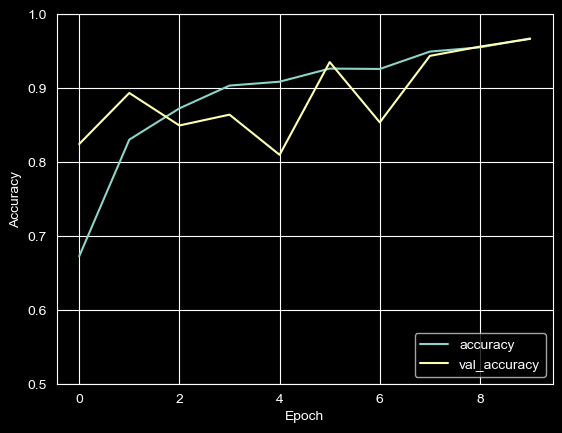

mobile model size: 25.39 MB


In [13]:
# MobileNet
def mobilenet_transfer(train_imgs, val_imgs, test_imgs, img_height, img_width, img_chns, classes):
    num_classes = len(classes)

    mobilenet = MobileNetV2(
        weights='imagenet',
        input_shape=(img_height, img_width, img_chns),
        include_top=False,
        pooling='avg'  # outputs a vector already (GlobalAveragePooling2D)
    )

    for layer in mobilenet.layers:
        layer.trainable = False

    x = mobilenet.output
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    mobilenet_model = Model(inputs=mobilenet.input, outputs=output_layer)
    mobilenet_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

    trained_mobilenet = mobilenet_model.fit(
        train_imgs,
        epochs=10,
        validation_data=val_imgs
    )
    return mobilenet_model, trained_mobilenet


# Training
mobilenet_model, trained_mobilenet = mobilenet_transfer(
    train_imgs, val_imgs, test_imgs, img_height, img_width, img_chns, classes
)

# Evaluation
fig4 = plt.gcf()
plt.plot(trained_mobilenet.history["accuracy"], label="accuracy")
plt.plot(trained_mobilenet.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0.5, 1])
plt.legend(loc="lower right")
plt.show()

# Saving
sizes = {}

# Save under a predictable folder next to this script (more portable than hardcoding)
save_dir = os.path.join(script_dir, "saved_models")
os.makedirs(save_dir, exist_ok=True)

mobile_save_path = os.path.join(save_dir, "mobile.keras")
mobilenet_model.save(mobile_save_path)

sizes["mobile"] = os.path.getsize(mobile_save_path) / 1e6
mobile = sizes["mobile"]
print(f"mobile model size: {sizes['mobile']:.2f} MB")

mobilenet_model_evaluation = evaluate_model(mobilenet_model, test_imgs, num_classes=num_classes)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7962 - loss: 0.4303 - val_accuracy: 0.9226 - val_loss: 0.2184
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 993ms/step - accuracy: 0.9127 - loss: 0.2250 - val_accuracy: 0.9247 - val_loss: 0.1765
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 58s 971ms/step - accuracy: 0.9227 - loss: 0.1880 - val_accuracy: 0.9561 - val_loss: 0.1248
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 58s 970ms/step - accuracy: 0.9389 - loss: 0.1541 - val_accuracy: 0.9142 - val_loss: 0.1905
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 59s 985ms/step - accuracy: 0.9451 - loss: 0.1404 - val_accuracy: 0.9582 - val_loss: 0.1019
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 58s 974ms/step - accuracy: 0.9498 - loss: 0.1117 - val_accuracy: 0.9644 - val_loss: 0.0881
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 58s 975ms/step - accuracy: 0.9624 - loss: 0.0913 - val_accuracy: 0.9833 - val_loss: 0.0706
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 58s 973ms/step - accuracy: 0.9660 - loss: 0.0892 - val_accurac

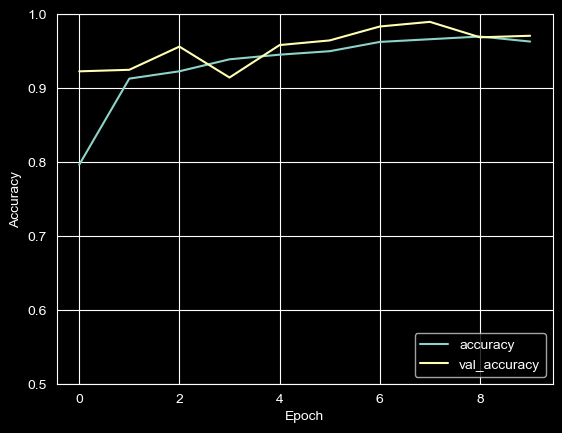

Effnet model size: 141.26 MB


In [14]:
# EfficientNet
def effnet_transfer(train_imgs, val_imgs, test_imgs, img_height, img_width, img_chns, classes):
    num_classes = len(classes)

    effnet = EfficientNetB5(
        weights='imagenet',
        input_shape=(img_height, img_width, img_chns),
        include_top=False,
        pooling='avg'  # outputs a vector already (GlobalAveragePooling2D)
    )

    for layer in effnet.layers:
        layer.trainable = False

    x = effnet.output
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    effnet_model = Model(inputs=effnet.input, outputs=output_layer)
    effnet_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

    trained_effnet = effnet_model.fit(
        train_imgs,
        epochs=10,
        validation_data=val_imgs
    )
    return effnet_model, trained_effnet


# Training
effnet_model, trained_effnet = effnet_transfer(
    train_imgs, val_imgs, test_imgs, img_height, img_width, img_chns, classes
)

# Evaluation
fig5 = plt.gcf()
plt.plot(trained_effnet.history["accuracy"], label="accuracy")
plt.plot(trained_effnet.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim([0.5, 1])
plt.legend(loc="lower right")
plt.show()

# Saving
sizes = {}

# Save under a predictable folder next to this script (more portable than hardcoding)
save_dir = os.path.join(script_dir, "saved_models")
os.makedirs(save_dir, exist_ok=True)

effnet_save_path = os.path.join(save_dir, "effnet.keras")
effnet_model.save(effnet_save_path)

sizes["effnet"] = os.path.getsize(effnet_save_path) / 1e6
effnet = sizes["effnet"]
print(f"Effnet model size: {sizes['effnet']:.2f} MB")

effnet_model_evaluation = evaluate_model(effnet_model, test_imgs, num_classes=num_classes)

In [19]:

values = {
        'accuracy': [
            vgg_model_evaluation['accuracy'],
            resnet_model_evaluation['accuracy'],
            mobilenet_model_evaluation['accuracy'],
            effnet_model_evaluation['accuracy'],
            custom_model_evaluation['accuracy'],

        ],
        'f1_score': [
            vgg_model_evaluation['f1_score'],
            resnet_model_evaluation['f1_score'],
            mobilenet_model_evaluation['f1_score'],
            effnet_model_evaluation['f1_score'],
            custom_model_evaluation['f1_score'],
        ],
        'size': [
            vgg16,
            resnet,
            mobile,
            effnet,
            custom
        ]
    }

df = pd.DataFrame(values, index=['vgg', 'resnet', 'mobilenet', 'efficientnet', 'custom'])
print(df)

              accuracy  f1_score        size
vgg           0.984925  0.984922   65.278682
resnet        0.979899  0.979895  120.212253
mobilenet     0.951424  0.951317   25.385568
efficientnet  0.971524  0.971432  141.260313
custom        0.988275  0.988264   45.602549
